# Đồ án: Phân tích & Thiết kế Thực nghiệm trong Đầu tư Chứng khoán

## Tên đề tài

**Phân tích thực nghiệm Bẫy Giá Trị và so sánh hiệu năng các mô hình dự báo giá trên thị trường chứng khoán Việt Nam.**

---

## 1. Giới thiệu & Lý do chọn đề tài

### 1.1. Bối cảnh và Tính cấp thiết

Trong bối cảnh thị trường chứng khoán Việt Nam ngày càng phát triển, nhà đầu tư phải đối mặt với hai thách thức lớn: (1) **lựa chọn cổ phiếu tiềm năng** trong hàng ngàn mã và (2) **xác định thời điểm giao dịch tối ưu**. Chiến lược đầu tư giá trị, một phương pháp kinh điển, thường được áp dụng để giải quyết thách thức đầu tiên bằng cách tìm kiếm các cổ phiếu bị định giá thấp (P/E thấp). Tuy nhiên, phương pháp này tiềm ẩn rủi ro "bẫy giá trị" (value trap) – những cổ phiếu rẻ nhưng có nền tảng yếu kém. Đồng thời, việc dự báo giá ngắn hạn bằng các mô hình chuỗi thời gian như ARIMA và Prophet có thể hỗ trợ giải quyết thách thức thứ hai.

Đề tài này đề xuất một framework toàn diện, kết hợp cả hai yếu tố trên: trước hết, xây dựng một phương pháp thực nghiệm để phân biệt giữa cổ phiếu "giá trị thực sự" và "bẫy giá trị"; sau đó, sử dụng kết quả này để lựa chọn các cổ phiếu tiêu biểu và so sánh hiệu quả của hai mô hình dự báo phổ biến.

### 1.2. Nghiên cứu trước và Tính mới của Đề tài

*   **Nền tảng học thuật:** Các nghiên cứu về "Value Premium" trên thế giới (Fama & French, 1992) và tại Việt Nam (Le Quy Duong, 2024) đã khẳng định sự tồn tại của hiệu ứng giá trị. Các mô hình ARIMA và Prophet cũng đã được so sánh rộng rãi trên nhiều thị trường quốc tế.
*   **Khoảng trống nghiên cứu & Tính mới:**
    1.  **Kết hợp Phân tích Cơ bản và Dự báo Kỹ thuật:** Đề tài tạo ra một cầu nối logic giữa việc sàng lọc cổ phiếu dựa trên chất lượng cơ bản (tránh "value trap") và việc dự báo giá ngắn hạn, một hướng tiếp cận toàn diện ít được khai thác.
    2.  **Phương pháp Thực nghiệm Chặt chẽ cho Thị trường Việt Nam:** Nghiên cứu này áp dụng phương pháp phân loại kép (double sort) để kiểm định "value trap" và sử dụng các kiểm định thống kê (t-test, Diebold-Mariano test) để so sánh hiệu năng các mô hình dự báo một cách nghiêm ngặt trên dữ liệu Việt Nam.
    3.  **Đánh giá Mô hình trong Bối cảnh Cụ thể:** So sánh ARIMA và Prophet không chỉ trên phương diện độ chính xác chung mà còn xem xét hiệu quả của chúng đối với các loại cổ phiếu có đặc tính khác nhau (value thật vs. value trap), mang lại kết quả có tính ứng dụng cao.

---

## 2. Mục tiêu và các Giả thuyết Nghiên cứu

### 2.1. Phần I: Phân tích và Kiểm định "Bẫy Giá trị" (Value Trap)

*   **Mục tiêu:** Xây dựng và kiểm định một phương pháp thực nghiệm để phân biệt giữa cổ phiếu giá trị thực sự (có khả năng tăng trưởng) và bẫy giá trị (rẻ nhưng yếu kém) trong nhóm cổ phiếu có P/E thấp.
*   **Giả thuyết:**
    *   **H0:** Trong nhóm các cổ phiếu có P/E thấp, không có sự khác biệt có ý nghĩa thống kê về lợi nhuận tương lai giữa các cổ phiếu có chỉ số chất lượng (như ROE, tăng trưởng doanh thu) cao và các cổ phiếu có chỉ số chất lượng thấp.
    *   **H1:** Trong nhóm các cổ phiếu có P/E thấp, các cổ phiếu có chỉ số chất lượng cao hơn sẽ mang lại lợi nhuận trung bình trong kỳ tiếp theo cao hơn một cách có ý nghĩa thống kê so với các cổ phiếu có chỉ số chất lượng thấp.

### 2.2. Phần II: So sánh Hiệu quả Dự báo của ARIMA và Prophet

*   **Mục tiêu:** Xác định mô hình dự báo chuỗi thời gian (ARIMA hay Prophet) phù hợp và chính xác hơn cho việc dự báo giá ngắn hạn của các cổ phiếu trên thị trường Việt Nam.
*   **Giả thuyết:**
    *   **H0:** Không có sự khác biệt có ý nghĩa thống kê về sai số dự báo (đo bằng MAE, RMSE, MAPE) giữa mô hình ARIMA và mô hình Prophet.
    *   **H1:** Có sự khác biệt có ý nghĩa thống kê về sai số dự báo giữa hai mô hình, cho thấy một mô hình hoạt động hiệu quả hơn mô hình còn lại trong bối cảnh cụ thể.

---

## 3. Phương pháp và Thiết kế Thực nghiệm

### 3.1. Thu thập và Tiền xử lý Dữ liệu

| STT | Tên Cột | Ý nghĩa | Vai trò trong phân tích |
| :-- | :--- | :--- | :--- |
| **I.** | **DỮ LIỆU PHẦN “BẪY GIÁ TRỊ”** | | | | |
| 1 | `Ticker` | Mã cổ phiếu | Xác định cổ phiếu |
| 2 | `P/E` | Tỷ số giá trên thu nhập | Xác định cổ phiếu "giá trị" (P/E thấp) | 
| 3 | `ROE` | Tỷ suất sinh lời trên vốn CSH | Đánh giá chất lượng, khả năng sinh lời | 
| 4 | `Revenue_Growth` | Tăng trưởng doanh thu | Đánh giá tốc độ phát triển, tiềm năng | 
| 5 | `Debt_to_Equity` | Tỷ lệ Nợ / Vốn CSH | Đánh giá rủi ro tài chính | 
| 6 | `Price_t` | Giá tại thời điểm hình thành DM | Tính lợi nhuận tương lai | 
| 7 | `Price_t+1y` | Giá sau 1 năm | Tính lợi nhuận tương lai |
| 8 | `Return_1y` | Lợi nhuận 1 năm | Tính từ `Price_t` và `Price_t+1y` | `(P_t+1y - P_t) / P_t` |
| **II.** | **DỮ LIỆU PHẦN “ARIMA vs PROPHET”** | | | | |
| 9 | `time` | Ngày giao dịch | Trục thời gian | 
| 10 | `close` | Giá đóng cửa đã điều chỉnh | Dữ liệu đầu vào chính cho dự báo |

### 3.2. Quy trình Thực nghiệm

1.  **Phân tích Value Trap (Phần I):**
    *   **Bước 1:** Tại đầu mỗi kỳ (ví dụ: ngày giao dịch cuối cùng của năm), thu thập dữ liệu tài chính (P/E, ROE,...) cho 100 cổ phiếu sàn HOSE (VN100).
    *   **Bước 2:** Lọc ra 30% số cổ phiếu có P/E thấp nhất (và dương).
    *   **Bước 3 (Double Sort):** Trong danh mục P/E thấp, tiếp tục phân chia thành 2 nhóm dựa trên một chỉ số chất lượng (ví dụ: 50% có ROE cao nhất và 50% có ROE thấp nhất). Lặp lại với các chỉ số chất lượng khác.
    *   **Bước 4:** Thu thập giá điều chỉnh tại đầu kỳ (`Price_t`) và cuối kỳ (`Price_t+1y`) để tính lợi nhuận 1 năm (`Return_1y`) cho mỗi cổ phiếu.
    *   **Bước 5 (Kiểm định H₁):** Sử dụng **t-test cho hai mẫu độc lập** để so sánh lợi nhuận trung bình giữa nhóm "chất lượng cao" và "chất lượng thấp".

2.  **So sánh Mô hình Dự báo (Phần II):**
    *   **Bước 1:** Lựa chọn các cổ phiếu tiêu biểu từ kết quả của Phần I (ví dụ: 2 mã "value thật", 1 mã "value trap", 1 mã baseline (có nguồn vốn lớn và uy tín)).
    *   **Bước 2:** Thu thập dữ liệu chuỗi thời gian giá đóng cửa điều chỉnh trong 5 năm gần nhất.
    *   **Bước 3 (Thiết kế thực nghiệm):** Sử dụng **Time Series Cross-Validation** để tạo ra nhiều cặp train/test. Đây là phương pháp tốt nhất để đánh giá mô hình chuỗi thời gian một cách khách quan. Quy trình: "cuộn" cửa sổ huấn luyện qua thời gian và dự báo cho điểm tiếp theo.
    *   **Bước 4 (Xây dựng mô hình):**
        *   **Mô hình ARIMA:**
            Xử lý tính không dừng (Non-stationarity): Chuỗi giá gần như chắc chắn là không dừng. Mô hình ARIMA xử lý điều này thông qua tham số d (bậc sai phân). Quy trình:
            * Xác định bậc d cần thiết để làm cho chuỗi dừng.
            * Sau khi tìm được d, nó sẽ tìm các bậc p và q tối ưu cho chuỗi đã được lấy sai phân.

        *   **Mô hình Prophet:**
            Xử lý chuỗi giá một cách tự nhiên. Nó không yêu cầu dữ liệu phải có tính dừng. Prophet sẽ tự động phân rã chuỗi giá thành các thành phần:

            * Trend (Xu hướng): Một đường cong (thường là tuyến tính hoặc logistic) thể hiện xu hướng tăng/giảm dài hạn.

            * Seasonality (Mùa vụ): Các quy luật lặp lại theo tuần, theo năm.

            * Holidays (Ngày nghỉ lễ): Tác động của các ngày đặc biệt.

            Quy trình: chuẩn bị dữ liệu với cột ds và y (giá) và huấn luyện.

    *   **Bước 5 (Đánh giá):** Dự báo trên các tập test và tính toán các chỉ số lỗi (MAE, RMSE, MAPE) cho mỗi lần lặp của cross-validation. Chỉ số lỗi:

        * RMSE và MAE: Vẫn là các chỉ số chính. Tuy nhiên, bây giờ chúng sẽ có đơn vị là đồng (VNĐ). Ví dụ, MAE = 500 có nghĩa là trung bình mô hình dự báo sai lệch 500 đồng.

        * MAPE (Mean Absolute Percentage Error): Trở nên cực kỳ quan trọng khi dự báo giá. Nó cho biết sai số trung bình là bao nhiêu phần trăm so với giá thực tế, giúp so sánh hiệu quả giữa các cổ phiếu có thị giá khác nhau (ví dụ: dự báo VNM giá 80.000 và HPG giá 30.000).

    *   **Bước 6 (Kiểm định):** Sử dụng **Diebold-Mariano test** trên chuỗi các sai số dự báo để so sánh hiệu năng của hai mô hình.

---

## 4. Kế hoạch Thực hiện

| Bước | Nội dung | Công cụ & Thư viện |
| :--- | :--- | :--- |
| 1 | Thu thập & xử lý dữ liệu Phần I (Chỉ số tài chính) | `vnstock` (financial_ratio), `pandas` |
| 2 | Thực hiện Double Sort, tính lợi nhuận & kiểm định t-test | `pandas`, `numpy`, `scipy.stats` |
| 3 | Lựa chọn cổ phiếu & Thu thập dữ liệu Phần II (Giá) | `vnstock` (stock_historical_data), `pandas` |
| 4 | Xây dựng mô hình ARIMA (ADF, ACF/PACF) | `statsmodels` |
| 5 | Xây dựng mô hình Prophet | `prophet` |
| 6 | Thiết lập Cross-Validation & Chạy Backtest | `sklearn` (TimeSeriesSplit), vòng lặp for |
| 7 | Tính toán chỉ số lỗi & Kiểm định Diebold-Mariano/Paired t-test | `sklearn.metrics`, `scipy.stats` |
| 8 | Trực quan hóa kết quả (biểu đồ lợi nhuận, biểu đồ dự báo) | `matplotlib`, `seaborn` |
| 9 | Viết báo cáo & Tổng hợp kết luận | Word / LaTeX |

## Thư viện cần thiết

In [46]:
import pandas as pd
import numpy as np
from vnstock import *
from datetime import datetime, timedelta
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import random

from statsmodels.tsa.stattools import adfuller # Dùng để kiểm định tính dừng
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Để vẽ biểu đồ ACF/PACF
from statsmodels.tsa.arima.model import ARIMA # Mô hình ARIMA chính
from prophet import Prophet
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
from prophet.make_holidays import make_holidays_df
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from dieboldmariano import dm_test

## Phần I

### Thu thập dữ liệu

In [ ]:
stock = Vnstock().stock(symbol='CMV', source='VCI') # Khởi tạo đối tượng stock
vn100_symbols = stock.listing.symbols_by_group('VN100').tolist() # lấy top 30

In [ ]:
# Tạo thư mục cache để lưu dữ liệu tạm
CACHE_DIR = "data_cache"
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

def retry_on_failure(func, max_retries=3, delay=2, **kwargs):
    for i in range(max_retries):
        try:
            # Thêm một khoảng thời gian chờ ngẫu nhiên nhỏ
            time.sleep(delay * (i + 1) + random.uniform(0, 1))
            return func(**kwargs)
        except Exception as e:
            print(f" -> Lần thử {i+1}/{max_retries} thất bại. Lỗi: {e}. Thử lại...")
    print(f" -> Thất bại sau {max_retries} lần thử.")
    return None

# --- 2. HÀM CHÍNH ĐỂ THU THẬP DỮ LIỆU (ĐÃ TỐI ƯU HÓA) ---

def get_data_for_value_trap_analysis(symbols, analysis_years):
    """
    Thu thập và tổng hợp dữ liệu cho phân tích Value Trap qua nhiều năm.
    (Phiên bản tối ưu với retry & cache, giữ cấu trúc và tên biến gốc)
    
    Args:
        symbols (list): Danh sách các mã cổ phiếu.
        analysis_years (list): Danh sách các năm để hình thành danh mục.
        
    Returns:
        pandas.DataFrame: DataFrame chứa toàn bộ dữ liệu đã được tổng hợp.
    """
    all_years_data = []

    for year in analysis_years:
        # refresh stock figure
        stock = Vnstock().stock(symbol='CMV', source='VCI')
        
        # **TỐI ƯU HÓA 1: SỬ DỤNG CACHE**
        cache_file_path = os.path.join(CACHE_DIR, f'value_trap_data_{year}.csv')
        if os.path.exists(cache_file_path):
            print(f"\n Tìm thấy file cache cho năm {year}. Đang tải từ cache...")
            df_cached = pd.read_csv(cache_file_path)
            all_years_data.append(df_cached)
            print(f"  Đã tải thành công {len(df_cached)} dòng từ '{cache_file_path}'.")
            continue

        print(f"\n{'='*20} BẮT ĐẦU THU THẬP DỮ LIỆU MỚI CHO NĂM {year} {'='*20}")
        yearly_data = []
        
        # 1. Lấy dữ liệu tài chính
        for i, symbol in enumerate(symbols):
            print(f"  [{year}] Đang xử lý mã {i+1}/{len(symbols)}: {symbol}...", end="")
            
            # **TỐI ƯU HÓA 2: SỬ DỤNG RETRY**
            try:
                # Lấy các chỉ số P/E, ROE, D/E với cơ chế retry
                df_ratio = retry_on_failure(stock.finance.ratio, symbol=symbol, period='y', lang='vi')
                # Lấy tăng trưởng doanh thu với cơ chế retry
                df_income = retry_on_failure(stock.finance.income_statement, symbol=symbol, period='y', lang='vi')
                
                # Kiểm tra kết quả sau khi retry
                if df_ratio is None or df_income is None:
                    print(" -> Không thể lấy dữ liệu sau nhiều lần thử.")
                    continue

                # Lọc dữ liệu theo năm (tên cột đã được sửa cho vnstock v2)
                df_ratio.columns = ['_'.join(col).strip() for col in df_ratio.columns.values]
                ratio_row = df_ratio[df_ratio['Meta_Năm'] == year]
                income_row = df_income[df_income['Năm'] == year]
                
                if not ratio_row.empty and not income_row.empty:
                    pe_ratio = ratio_row['Chỉ tiêu định giá_P/E'].iloc[0]
                    roe_percent = ratio_row['Chỉ tiêu khả năng sinh lợi_ROE (%)'].iloc[0]
                    de_ratio = ratio_row['Chỉ tiêu cơ cấu nguồn vốn_Nợ/VCSH'].iloc[0]
                    revenue_growth_percent = income_row['Tăng trưởng doanh thu (%)'].iloc[0]
                    
                    yearly_data.append({
                        'Ticker': symbol,
                        'Formation_Year': year,
                        'P/E': pe_ratio,
                        'ROE': roe_percent / 100.0 if pd.notna(roe_percent) else None,
                        'Revenue_Growth': revenue_growth_percent / 100.0 if pd.notna(revenue_growth_percent) else None,
                        'Debt_to_Equity': de_ratio
                    })
                    print(" -> OK")
                else:
                    print(" -> Không đủ dữ liệu tài chính cho năm này.")           
            
            except Exception as e:
                # Bắt các lỗi không mong muốn khác
                print(f" -> Lỗi không xác định: {e}")
                continue 
        
        if not yearly_data:
            print(f"Không có dữ liệu tài chính nào được thu thập cho năm {year}.")
            continue
        
        # tạo dataframe    
        df_financials = pd.DataFrame(yearly_data)
        
        # 2. Lấy dữ liệu giá để tính lợi nhuận
        print(f"\n  [{year}] Đang lấy dữ liệu giá để tính lợi nhuận 1 năm...")
        
        start_price_date = f"{year}-12-31"
        end_price_date = f"{year+1}-12-31"
        
        prices_t = []
        prices_t_plus_1y = []

        for ticker in df_financials['Ticker']:
            try:
                # **TỐI ƯU HÓA 2: SỬ DỤNG RETRY**
                price_hist = retry_on_failure(stock.quote.history, symbol=ticker, 
                                              start=f"{year}-12-01", end=f"{year+2}-01-31", 
                                              interval='1D')
                if price_hist is None:
                    raise ValueError("Không thể lấy dữ liệu giá sau nhiều lần thử.")

                price_hist['time'] = pd.to_datetime(price_hist['time'])
                price_hist = price_hist.set_index('time')
                
                # Tìm ngày giao dịch gần nhất
                price_t = price_hist.asof(pd.to_datetime(start_price_date))['close']
                price_t_plus_1y = price_hist.asof(pd.to_datetime(end_price_date))['close']
                
                prices_t.append(price_t)
                prices_t_plus_1y.append(price_t_plus_1y)
            except Exception as e:
                # print(f"Lỗi khi lấy giá cho {ticker}: {e}") # Bỏ comment nếu muốn debug
                prices_t.append(None)
                prices_t_plus_1y.append(None)

        df_financials['Price_t'] = prices_t
        df_financials['Price_t+1y'] = prices_t_plus_1y
        
        # 3. Làm sạch và tính toán
        df_financials.dropna(subset=['Price_t', 'Price_t+1y'], inplace=True)
        if not df_financials.empty:
            df_financials['Return_1y'] = (df_financials['Price_t+1y'] - df_financials['Price_t']) / df_financials['Price_t']
            
            # Loại bỏ các giá trị vô lý
            df_financials.dropna(inplace=True)
            df_financials = df_financials[(df_financials['P/E'] > 0) & (df_financials['P/E'] < 100)] # Lọc P/E
            
            all_years_data.append(df_financials)
            print(f"  Hoàn thành thu thập dữ liệu cho năm {year}. Số mã hợp lệ: {len(df_financials)}")
            
            # **TỐI ƯU HÓA 1: LƯU VÀO CACHE**
            df_financials.to_csv(cache_file_path, index=False, encoding='utf-8-sig')
            print(f"  Đã lưu dữ liệu vào cache: '{cache_file_path}'")
        else:
            print(f"Không có dữ liệu giá hợp lệ cho năm {year}.")


    if not all_years_data:
        return pd.DataFrame()
        
    final_df = pd.concat(all_years_data, ignore_index=True)
    return final_df

In [ ]:
# Chọn các năm để phân tích
analysis_years_list = [2020, 2021, 2022, 2023]
df_value_analysis_final = get_data_for_value_trap_analysis(vn100_symbols, analysis_years_list)

if not df_value_analysis_final.empty:
    print("\n\nTỔNG HỢP DỮ LIỆU HOÀN TẤT")
    print("DataFrame kết quả:")
    print(df_value_analysis_final)
else:
    print("\n\nKHÔNG THU THẬP ĐƯỢC DỮ LIỆU NÀO SAU KHI TỔNG HỢP")


==================== BẮT ĐẦU THU THẬP DỮ LIỆU MỚI CHO NĂM 2023 ====================
  [2023] Đang xử lý mã 1/100: AAA... -> OK
  [2023] Đang xử lý mã 2/100: ACB...

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


 -> OK
  [2023] Đang xử lý mã 3/100: ANV... -> OK
  [2023] Đang xử lý mã 4/100: BCM... -> OK
  [2023] Đang xử lý mã 5/100: BID...

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


 -> OK
  [2023] Đang xử lý mã 6/100: BMP... -> OK
  [2023] Đang xử lý mã 7/100: BSI... -> OK
  [2023] Đang xử lý mã 8/100: BVH...

...

 -> OK
  [2023] Đang xử lý mã 91/100: VIC... -> OK
  [2023] Đang xử lý mã 92/100: VIX... -> OK
  [2023] Đang xử lý mã 93/100: VJC... -> OK
  [2023] Đang xử lý mã 94/100: VND...

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


 -> OK
  [2023] Đang xử lý mã 95/100: VNM... -> OK
  [2023] Đang xử lý mã 96/100: VPB...

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


 -> OK
  [2023] Đang xử lý mã 97/100: VPI... -> OK
  [2023] Đang xử lý mã 98/100: VRE... -> OK
  [2023] Đang xử lý mã 99/100: VSC... -> OK
  [2023] Đang xử lý mã 100/100: VTP... -> OK

  [2023] Đang lấy dữ liệu giá để tính lợi nhuận 1 năm...
  Hoàn thành thu thập dữ liệu cho năm 2023. Số mã hợp lệ: 88
  Đã lưu dữ liệu vào cache: 'data_cache\value_trap_data_2023.csv'


TỔNG HỢP DỮ LIỆU HOÀN TẤT
DataFrame kết quả:
   Ticker  Formation_Year        P/E       ROE  Revenue_Growth  \
0     AAA            2023  14.265425  0.000533       -0.002133   
1     ACB            2023   6.778138  0.002480        0.000512   
2     BCM            2023  26.054725  0.001372        0.047829   
3     BID            2023  14.155054  0.001895        0.001030   
4     BMP            2023   9.459953  0.003920        0.000366   
..    ...             ...        ...       ...             ...   
83    VPB            2023  13.744606  0.000820        0.002267   
84    VPI            2023  28.041669  0.001368       -0.

### Đọc và gộp dữ liệu

In [ ]:
df_2022 = pd.read_csv('data_cache/value_trap_data_2022.csv')
df_2023 = pd.read_csv('data_cache/value_trap_data_2023.csv')
df_2021 = pd.read_csv('data_cache/value_trap_data_2021.csv')
df_2020 = pd.read_csv('data_cache/value_trap_data_2020.csv')

In [78]:
list1=df_2022['Ticker'].tolist()
list2=df_2020['Ticker'].tolist()
list3=df_2021['Ticker'].tolist()
list4=df_2023['Ticker'].tolist()

def find_common_elements(*lists):
    return list(set.intersection(*map(set, lists)))

# Gọi hàm:
common = find_common_elements(list1, list2, list3, list4)
print("Giao của các list:", common)
print(len(common))

Giao của các list: ['HDB', 'GEX', 'BSI', 'KDH', 'IMP', 'CTR', 'VIB', 'POW', 'PVT', 'VHC', 'SIP', 'TPB', 'GAS', 'HHV', 'DCM', 'SZC', 'GVR', 'PTB', 'PNJ', 'FPT', 'VGC', 'PHR', 'CTS', 'AAA', 'BID', 'BCM', 'VPB', 'PAN', 'TCH', 'STB', 'SCS', 'GMD', 'VNM', 'REE', 'NLG', 'BWE', 'VSC', 'EVF', 'SHB', 'HPG', 'SAB', 'LPB', 'CMG', 'VHM', 'PC1', 'VRE', 'VCG', 'BVH', 'MSB', 'BMP', 'NAB', 'CTG', 'VCB', 'DGW', 'PDR', 'TCB', 'DPM', 'PPC', 'VPI', 'ACB', 'VCI', 'MBB', 'HCM', 'TLG', 'VIX', 'FTS', 'PLX', 'SBT', 'NT2', 'HDG', 'VND', 'HDC', 'DGC', 'SSI', 'EIB', 'KBC', 'VTP']
77


In [81]:
df_2020 = df_2020[df_2020['Ticker'].isin(common)]
df_2021 = df_2021[df_2021['Ticker'].isin(common)]
df_2022 = df_2022[df_2022['Ticker'].isin(common)]
df_2023 = df_2023[df_2023['Ticker'].isin(common)]

# Gộp dữ liệu từ hai năm lại
df1 = pd.concat([df_2020, df_2021], ignore_index=True)
df2 = pd.concat([df_2022, df_2023], ignore_index=True)
df_analysis = pd.concat([df1, df2], ignore_index=True)

print("Đã đọc và hợp nhất dữ liệu thành công.")
print(df_analysis.info())

Đã đọc và hợp nhất dữ liệu thành công.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ticker          308 non-null    object 
 1   Formation_Year  308 non-null    int64  
 2   P/E             308 non-null    float64
 3   ROE             308 non-null    float64
 4   Revenue_Growth  308 non-null    float64
 5   Debt_to_Equity  308 non-null    float64
 6   Price_t         308 non-null    float64
 7   Price_t+1y      308 non-null    float64
 8   Return_1y       308 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 21.8+ KB
None


In [ ]:
df_analysis.to_csv('data.csv') # Xuất ra file csv để lưu

### EDA và phân tích

In [32]:
df_analysis = pd.read_csv('data.csv')
df_analysis

,Unnamed: 0,Ticker,Formation_Year,P/E,ROE,Revenue_Growth,Debt_to_Equity,Price_t,Price_t+1y,Return_1y
0,0,AAA,2020,13.783848,0.000721,0.001545,1.129596,12.22,19.40,0.587561
1,1,ACB,2020,9.143859,0.002431,0.001011,11.540286,10.54,16.18,0.535104
2,2,BCM,2020,29.706362,0.001206,-0.003027,1.879681,39.02,61.70,0.581240
3,3,BID,2020,23.568908,0.000890,-0.000261,18.042690,27.80,27.21,-0.021223
4,4,BMP,2020,9.210785,0.002115,0.001252,0.223029,40.66,41.24,0.014265
...,...,...,...,...,...,...,...,...,...,...
303,303,VPB,2023,13.744606,0.000820,0.002267,4.848305,17.75,18.69,0.052958
304,304,VPI,2023,28.041669,0.001368,-0.008230,2.159069,45.83,59.80,0.304822
305,305,VRE,2023,12.447600,0.001238,0.001239,0.259786,23.30,17.15,-0.263948
306,306,VSC,2023,29.465720,0.000436,0.002039,0.575726,14.16,12.34,-0.128531



==================== PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) ====================

--- 1. Thống kê mô tả các chỉ số ---
              P/E         ROE  Revenue_Growth  Debt_to_Equity   Return_1y
count  308.000000  308.000000      308.000000      308.000000  308.000000
mean    17.017256    0.001661        0.002083        3.465263    0.273814
std     10.635583    0.001000        0.007039        4.581067    0.636417
min      2.412050    0.000151       -0.009881        0.029143   -0.805261
25%      9.846686    0.000899       -0.000487        0.578508   -0.113098
50%     14.154510    0.001463        0.000979        1.419115    0.169165
75%     21.489748    0.002209        0.003283        3.398550    0.548112
max     77.928755    0.006484        0.067721       19.406761    3.429043

--- 2. Phân tích phân phối của các biến ---


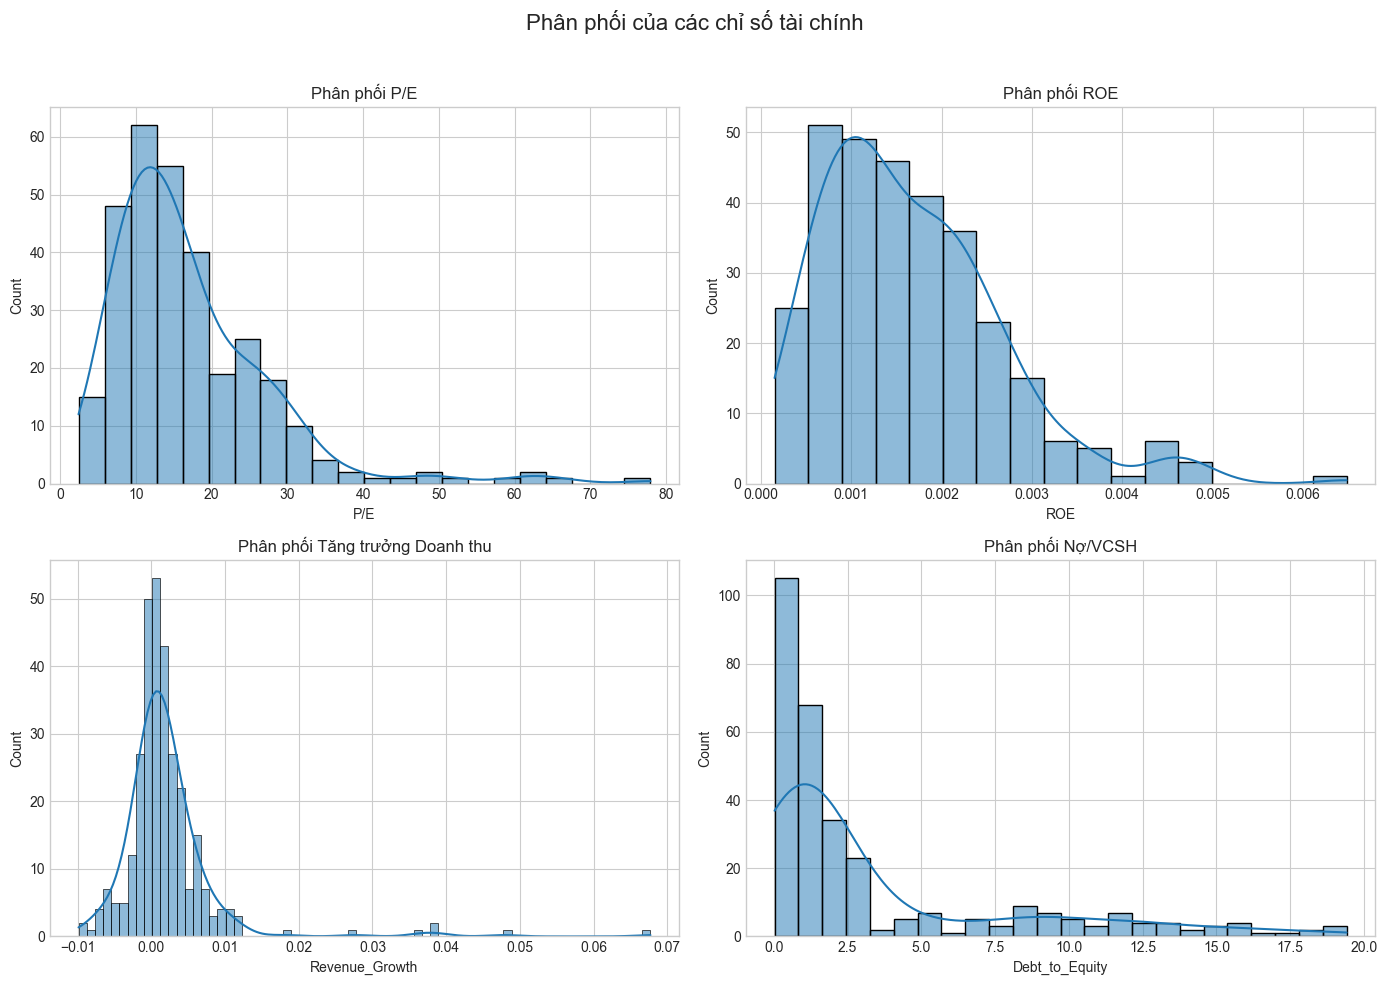


--- 3. Ma trận tương quan giữa các biến ---


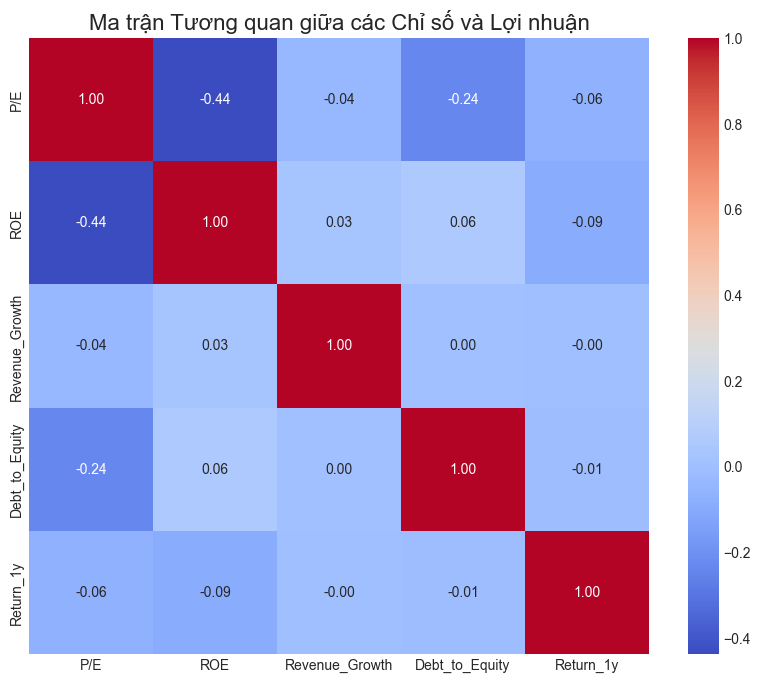

In [17]:
def perform_eda(df):
    """Thực hiện Phân tích Dữ liệu Khám phá (EDA)."""
    print("\n" + "="*20 + " PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) " + "="*20)
    
    # 1. Thống kê mô tả
    print("\n--- 1. Thống kê mô tả các chỉ số ---")
    print(df[['P/E', 'ROE', 'Revenue_Growth', 'Debt_to_Equity', 'Return_1y']].describe())
    
    # 2. Phân tích phân phối
    print("\n--- 2. Phân tích phân phối của các biến ---")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Phân phối của các chỉ số tài chính', fontsize=16)
    
    sns.histplot(df['P/E'], kde=True, ax=axes[0, 0]).set_title('Phân phối P/E')
    sns.histplot(df['ROE'], kde=True, ax=axes[0, 1]).set_title('Phân phối ROE')
    sns.histplot(df['Revenue_Growth'], kde=True, ax=axes[1, 0]).set_title('Phân phối Tăng trưởng Doanh thu')
    sns.histplot(df['Debt_to_Equity'], kde=True, ax=axes[1, 1]).set_title('Phân phối Nợ/VCSH')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # 3. Phân tích tương quan
    print("\n--- 3. Ma trận tương quan giữa các biến ---")
    corr_matrix = df[['P/E', 'ROE', 'Revenue_Growth', 'Debt_to_Equity', 'Return_1y']].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Ma trận Tương quan giữa các Chỉ số và Lợi nhuận', fontsize=16)
    plt.show()
    
perform_eda(df_analysis)

In [20]:
# Kiểm định Bẫy giá trị dựa trên xếp hạng các yếu tố (tổng hợp)
def create_composite_quality_score(df):
    """Tạo điểm chất lượng tổng hợp dựa trên xếp hạng."""
    df_quality = df.copy()
    # Xếp hạng: ROE và Revenue Growth càng cao càng tốt
    df_quality['ROE_Rank'] = df_quality['ROE'].rank(pct=True)
    df_quality['Growth_Rank'] = df_quality['Revenue_Growth'].rank(pct=True)
    # Xếp hạng: Debt to Equity càng thấp càng tốt
    df_quality['Debt_Rank'] = df_quality['Debt_to_Equity'].rank(pct=True, ascending=False)
    
    # Điểm chất lượng là trung bình của các điểm hạng
    df_quality['Quality_Score'] = df_quality[['ROE_Rank', 'Growth_Rank', 'Debt_Rank']].mean(axis=1)
    return df_quality

def perform_double_sort_and_test_all(df_year, value_metric='P/E', low_value_percentile=0.3):
    """
    Thực hiện phân tích Double Sort cho một năm và trả về bảng kết quả.
    Sử dụng Composite Quality Score.
    """
    # 1. Lọc theo chỉ số giá trị (P/E)
    value_threshold = df_year[value_metric].quantile(low_value_percentile)
    df_low_value = df_year[df_year[value_metric] <= value_threshold].copy()
    
    if len(df_low_value) < 10: return []
    
    # 2. Tạo điểm chất lượng tổng hợp
    df_low_value = create_composite_quality_score(df_low_value)
    
    # 3. Phân nhóm theo điểm chất lượng tổng hợp
    quality_threshold = df_low_value['Quality_Score'].quantile(0.5, interpolation='midpoint')
    high_quality_group = df_low_value[df_low_value['Quality_Score'] >= quality_threshold]
    low_quality_group = df_low_value[df_low_value['Quality_Score'] < quality_threshold]
    
    if len(high_quality_group) < 2 or len(low_quality_group) < 2: return []
    
    # 4. Tính toán và kiểm định
    return_col = 'Return_1y'
    avg_ret_hq = high_quality_group[return_col].mean()
    avg_ret_lq = low_quality_group[return_col].mean()
    
    # Sử dụng t-test cho 2 mẫu độc lập, kiểm định 1 phía
    t_stat, p_value = stats.ttest_ind(
        high_quality_group[return_col], 
        low_quality_group[return_col], 
        equal_var=False, # Welch's t-test, không yêu cầu phương sai bằng nhau
        alternative='greater' # H1: Lợi nhuận nhóm chất lượng cao > nhóm chất lượng thấp
    )
    
    return {
        'value_metric': value_metric,
        'quality_metric': 'Composite_Score',
        'high_quality_return': avg_ret_hq,
        'low_quality_return': avg_ret_lq,
        't_statistic': t_stat,
        'p_value': p_value
    }
    
def visualize_result_all(all_results):
    results_df = pd.DataFrame(all_results)
            
    print("\n\n" + "="*20 + " BẢNG TỔNG HỢP KẾT QUẢ " + "="*20)
    # Định dạng lại bảng cho dễ đọc
    results_df_display = results_df.copy()
    results_df_display['high_quality_return'] = results_df_display['high_quality_return'].apply(lambda x: f"{x:.2%}")
    results_df_display['low_quality_return'] = results_df_display['low_quality_return'].apply(lambda x: f"{x:.2%}")
    results_df_display['p_value'] = results_df_display['p_value'].round(4)
    results_df_display['t_statistic'] = results_df_display['t_statistic'].round(2)
    print(results_df_display[['year', 'quality_metric', 'high_quality_return', 'low_quality_return', 't_statistic', 'p_value']])

    # Trực quan hóa kết quả tổng hợp
    plot_df_melted = results_df.melt(
        id_vars=['year'], 
        value_vars=['high_quality_return', 'low_quality_return'],
        var_name='Group',
        value_name='Average_Return_1y'
    )
    plot_df_melted['Group'] = plot_df_melted['Group'].map({
        'high_quality_return': 'Giá trị & Chất lượng cao',
        'low_quality_return': 'Giá trị & Chất lượng thấp (Bẫy)'
    })

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=plot_df_melted, 
        x='year', 
        y='Average_Return_1y', 
        hue='Group',
        palette={'Giá trị & Chất lượng cao': '#2ca02c', 'Giá trị & Chất lượng thấp (Bẫy)': '#d62728'}
    )
    
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.title('Hiệu suất Lợi nhuận 1 năm của Chiến lược Value & Quality', fontsize=16, pad=20)
    plt.xlabel('Năm Hình thành Danh mục', fontsize=12)
    plt.ylabel('Lợi nhuận Trung bình 1 năm', fontsize=12)
    plt.legend(title='Loại Danh mục')
    plt.tight_layout()
    plt.show()

In [29]:
# Kiểm định Bẫy giá trị dựa trên riêng lẻ từng yếu tố
def perform_double_sort_and_test_each(df, year, value_metric='P/E', quality_metric='ROE', low_pe_percentile=0.3, high_quality_percentile=0.5):
    
    print(f"\n{'='*20} PHÂN TÍCH CHO NĂM {year} - Dựa trên chỉ số {quality_metric} {'='*20}")
    
    # Lọc dữ liệu cho năm phân tích
    df_year = df[df['Formation_Year'] == year].copy()
    
    if len(df_year) < 10: # Cần đủ mẫu để phân tích
        print(f"Không đủ dữ liệu cho năm {year} để phân tích.")
        return None, None

    # --- Bước 2.1: Sàng lọc theo chỉ số giá trị (P/E) ---
    pe_threshold = df_year[value_metric].quantile(low_pe_percentile)
    df_low_pe = df_year[df_year[value_metric] <= pe_threshold].copy()
    
    if len(df_low_pe) < 4: # Cần ít nhất 2 mẫu cho mỗi nhóm chất lượng
        print(f"Không đủ cổ phiếu trong nhóm P/E thấp của năm {year} để phân tích.")
        return None, None
        
    print(f"Tìm thấy {len(df_low_pe)} cổ phiếu trong nhóm P/E thấp (ngưỡng P/E <= {pe_threshold:.2f}).")
    
    # --- Bước 2.2: Sàng lọc theo chỉ số chất lượng (ROE, Revenue_Growth, ...) ---
    # Đối với ROE và Revenue_Growth, giá trị cao hơn là tốt hơn
    # Đối với Debt_to_Equity, giá trị thấp hơn là tốt hơn
    ascending_sort = (quality_metric == 'Debt_to_Equity')
    
    quality_threshold = df_low_pe[quality_metric].quantile(high_quality_percentile, interpolation='midpoint')
    
    if ascending_sort: 
        # Trường hợp D/E, thấp là tốt
        high_quality_group = df_low_pe[df_low_pe[quality_metric] <= quality_threshold]
        low_quality_group = df_low_pe[df_low_pe[quality_metric] > quality_threshold]
        print(f"Phân nhóm theo {quality_metric} (thấp là tốt): Ngưỡng <= {quality_threshold:.2f}")
    else: # Trường hợp ROE, Revenue Growth, cao là tốt
        high_quality_group = df_low_pe[df_low_pe[quality_metric] >= quality_threshold]
        low_quality_group = df_low_pe[df_low_pe[quality_metric] < quality_threshold]
        print(f"Phân nhóm theo {quality_metric} (cao là tốt): Ngưỡng >= {quality_threshold:.2f}")

    # Kiểm tra xem mỗi nhóm có đủ dữ liệu để kiểm định không
    if len(high_quality_group) < 2 or len(low_quality_group) < 2:
        print("Một trong hai nhóm chất lượng không có đủ mẫu để thực hiện t-test.")
        return None, None

    # --- Bước 3: Tính toán Hiệu suất ---
    avg_return_high_quality = high_quality_group['Return_1y'].mean()
    avg_return_low_quality = low_quality_group['Return_1y'].mean()
    
    print("\n--- Kết quả Hiệu suất Danh mục ---")
    print(f"Nhóm Low P/E - High {quality_metric}:")
    print(f"  Số lượng CP: {len(high_quality_group)}")
    print(f"  Lợi nhuận TB 1 năm: {avg_return_high_quality:.2%}")
    
    print(f"Nhóm Low P/E - Low {quality_metric} (Value Trap):")
    print(f"  Số lượng CP: {len(low_quality_group)}")
    print(f"  Lợi nhuận TB 1 năm: {avg_return_low_quality:.2%}")
    
    # --- Bước 4: Kiểm định Giả thuyết ---
    # H0: Lợi nhuận trung bình của hai nhóm là như nhau.
    # H1: Lợi nhuận trung bình của nhóm chất lượng cao > nhóm chất lượng thấp.
    # Chúng ta sẽ sử dụng t-test cho 2 mẫu độc lập.
    t_stat, p_value = stats.ttest_ind(
        high_quality_group['Return_1y'], 
        low_quality_group['Return_1y'], 
        equal_var=False, # Welch's t-test, không yêu cầu phương sai bằng nhau
        alternative='greater' # Kiểm định 1 phía: mean(high_quality) > mean(low_quality)
    )
    
    print("\n--- Kết quả Kiểm định Giả thuyết (T-test) ---")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value (one-tailed): {p_value:.4f}")
    
    alpha = 0.05
    if p_value < alpha:
        print(f"Kết luận: Tại mức ý nghĩa {alpha*100}%, có bằng chứng thống kê để bác bỏ H0.")
        print(f"==> Nhóm 'High {quality_metric}' có lợi nhuận cao hơn đáng kể so với nhóm 'Low {quality_metric}'.")
        print('     High quality group: ', high_quality_group['Ticker'].tolist())
        print('     Low quality group: ', low_quality_group['Ticker'].tolist())
        
    else:
        print(f"Kết luận: Tại mức ý nghĩa {alpha*100}%, không có đủ bằng chứng thống kê để bác bỏ H0.")
        print(f"==> Không có sự khác biệt đáng kể về lợi nhuận giữa hai nhóm.")
        
    # Lưu kết quả để tổng hợp
    results = {
        'year': year,
        'quality_metric': quality_metric,
        'high_quality_return': avg_return_high_quality,
        'low_quality_return': avg_return_low_quality,
        't_statistic': t_stat,
        'p_value': p_value
    }
    
    return high_quality_group, low_quality_group, results

def visualize_result_each(all_results):
    results_df = pd.DataFrame(all_results)
    
    print("\n\n" + "="*20 + " BẢNG TỔNG HỢP KẾT QUẢ " + "="*20)
    # Định dạng lại bảng cho dễ đọc
    results_df['high_quality_return'] = results_df['high_quality_return'].apply(lambda x: f"{x:.2%}")
    results_df['low_quality_return'] = results_df['low_quality_return'].apply(lambda x: f"{x:.2%}")
    results_df['p_value'] = results_df['p_value'].round(4)
    results_df['t_statistic'] = results_df['t_statistic'].round(2)
    print(results_df)

    # Trực quan hóa kết quả
    # Chuyển đổi lại kiểu dữ liệu để vẽ biểu đồ
    plot_df = pd.DataFrame(all_results)
    plot_df_melted = plot_df.melt(
        id_vars=['year', 'quality_metric'], 
        value_vars=['high_quality_return', 'low_quality_return'],
        var_name='Group',
        value_name='Average Return'
    )
    plot_df_melted['Group'] = plot_df_melted['Group'].map({
        'high_quality_return': 'Chất lượng cao',
        'low_quality_return': 'Chất lượng thấp (Bẫy giá trị)'
    })

    plt.style.use('seaborn-v0_8-whitegrid')
    g = sns.catplot(
        data=plot_df_melted, 
        x='year', 
        y='Average Return', 
        hue='Group', 
        col='quality_metric', 
        kind='bar',
        height=5, 
        aspect=1,
        palette={'Chất lượng cao': 'green', 'Chất lượng thấp (Bẫy giá trị)': 'red'}
    )
    
    # Định dạng đồ thị
    g.fig.suptitle('So sánh Hiệu suất 1 năm của Nhóm Chất lượng Cao vs. Thấp trong Danh mục P/E thấp', y=1.03, fontsize=16)
    g.set_axis_labels("Năm Hình thành Danh mục", "Lợi nhuận Trung bình 1 năm")
    g.set_titles("Phân loại theo: {col_name}")
    g._legend.remove()
    
    # Thêm định dạng % cho trục y
    for ax in g.axes.flat:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.legend()
    plt.show()



==================== BẮT ĐẦU KIỂM ĐỊNH BẪY GIÁ TRỊ ====================

--- Phân tích cho năm hình thành danh mục: 2020 ---
Kết quả phân loại theo Composite Quality Score:
  Lợi nhuận TB nhóm chất lượng cao: 80.53%
  Lợi nhuận TB nhóm chất lượng thấp: 69.17%
  T-statistic: 0.3867, P-value: 0.3520
  => KẾT LUẬN: Không có sự khác biệt ý nghĩa thống kê.

--- Phân tích cho năm hình thành danh mục: 2021 ---
Kết quả phân loại theo Composite Quality Score:
  Lợi nhuận TB nhóm chất lượng cao: -46.01%
  Lợi nhuận TB nhóm chất lượng thấp: -35.72%
  T-statistic: -1.5534, P-value: 0.9320
  => KẾT LUẬN: Không có sự khác biệt ý nghĩa thống kê.

--- Phân tích cho năm hình thành danh mục: 2022 ---
Kết quả phân loại theo Composite Quality Score:
  Lợi nhuận TB nhóm chất lượng cao: 29.56%
  Lợi nhuận TB nhóm chất lượng thấp: 48.01%
  T-statistic: -1.2608, P-value: 0.8879
  => KẾT LUẬN: Không có sự khác biệt ý nghĩa thống kê.

--- Phân tích cho năm hình thành danh mục: 2023 ---
Kết quả phân loại theo 

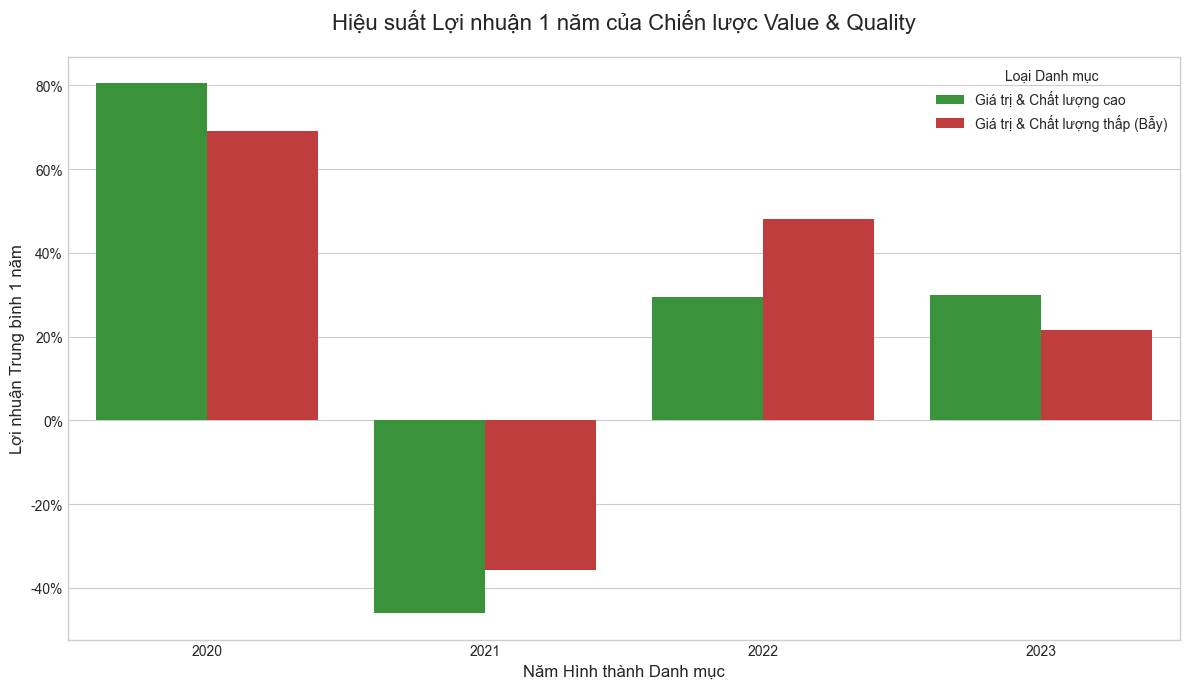

In [34]:
# Thực hiện kiểm định tổng hợp
analysis_years = sorted(df_analysis['Formation_Year'].unique())
all_results = []

print("\n\n" + "="*20 + " BẮT ĐẦU KIỂM ĐỊNH BẪY GIÁ TRỊ " + "="*20)
for year in analysis_years:
    print(f"\n--- Phân tích cho năm hình thành danh mục: {year} ---")
    df_year_data = df_main[df_main['Formation_Year'] == year]
    
    # Chạy kiểm định với chỉ số chất lượng tổng hợp
    result = perform_double_sort_and_test_all(df_year_data, value_metric='P/E')
    
    if result:
        # In kết quả chi tiết cho từng năm
        print(f"Kết quả phân loại theo Composite Quality Score:")
        print(f"  Lợi nhuận TB nhóm chất lượng cao: {result['high_quality_return']:.2%}")
        print(f"  Lợi nhuận TB nhóm chất lượng thấp: {result['low_quality_return']:.2%}")
        print(f"  T-statistic: {result['t_statistic']:.4f}, P-value: {result['p_value']:.4f}")
        if result['p_value'] < 0.05:
            print("  => KẾT LUẬN: Có ý nghĩa thống kê. Nhóm chất lượng cao hoạt động tốt hơn.")
        else:
            print("  => KẾT LUẬN: Không có sự khác biệt ý nghĩa thống kê.")
        
        # Thêm cột năm vào kết quả để tổng hợp
        result['year'] = year
        all_results.append(result)

# 3. Tổng hợp và Trực quan hóa kết quả
if all_results:
    visualize_result_all(all_results)
else:
    print("\nKhông có đủ dữ liệu để tạo kết quả tổng hợp.")


==================== PHÂN TÍCH CHO NĂM 2020 - Dựa trên chỉ số ROE ====================
Tìm thấy 23 cổ phiếu trong nhóm P/E thấp (ngưỡng P/E <= 11.30).
Phân nhóm theo ROE (cao là tốt): Ngưỡng >= 0.00

--- Kết quả Hiệu suất Danh mục ---
Nhóm Low P/E - High ROE:
  Số lượng CP: 12
  Lợi nhuận TB 1 năm: 80.29%
Nhóm Low P/E - Low ROE (Value Trap):
  Số lượng CP: 11
  Lợi nhuận TB 1 năm: 69.43%

--- Kết quả Kiểm định Giả thuyết (T-test) ---
T-statistic: 0.3686
P-value (one-tailed): 0.3584
Kết luận: Tại mức ý nghĩa 5.0%, không có đủ bằng chứng thống kê để bác bỏ H0.
==> Không có sự khác biệt đáng kể về lợi nhuận giữa hai nhóm.

==================== PHÂN TÍCH CHO NĂM 2020 - Dựa trên chỉ số Revenue_Growth ====================
Tìm thấy 23 cổ phiếu trong nhóm P/E thấp (ngưỡng P/E <= 11.30).
Phân nhóm theo Revenue_Growth (cao là tốt): Ngưỡng >= 0.00

--- Kết quả Hiệu suất Danh mục ---
Nhóm Low P/E - High Revenue_Growth:
  Số lượng CP: 12
  Lợi nhuận TB 1 năm: 84.31%
Nhóm Low P/E - Low Revenue_Grow

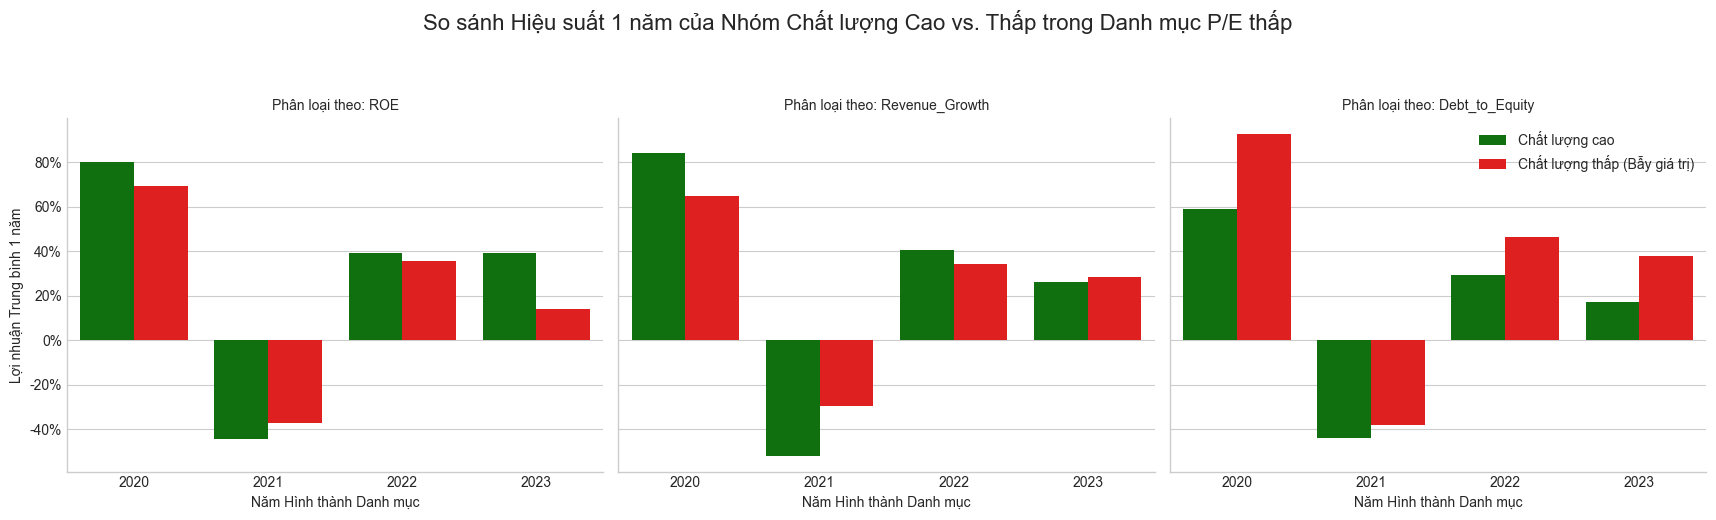

In [ ]:
# Thực hiện kiểm định các yếu tố riêng lẻ
analysis_years = df_analysis['Formation_Year'].unique()
quality_metrics_to_test = ['ROE', 'Revenue_Growth', 'Debt_to_Equity']
all_results = []

for year in analysis_years:
    for metric in quality_metrics_to_test:
        _, _, result_data = perform_double_sort_and_test_each(df_analysis, year, quality_metric=metric)
        if result_data:
            all_results.append(result_data)

if all_results:
    visualize_result_each(all_results)
else:
    print("\nKhông có đủ dữ liệu để tạo kết quả tổng hợp.")

Dữ liệu bị outlier lêch khá nhiều nên sử dụng winsorize để limit phần cực để phân bố giá trị đều hơn để kiểm tra xem kết quả t-test có thay đổi không


==================== PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) ====================

--- 1. Thống kê mô tả các chỉ số ---
              P/E         ROE  Revenue_Growth  Debt_to_Equity   Return_1y
count  308.000000  308.000000      308.000000      308.000000  308.000000
mean    16.274752    0.001622        0.001454        3.344475    0.245326
std      7.970304    0.000867        0.003518        4.217688    0.536924
min      5.894811    0.000412       -0.005316        0.201904   -0.585693
25%      9.846686    0.000899       -0.000487        0.578508   -0.113098
50%     14.154510    0.001463        0.000979        1.419115    0.169165
75%     21.489748    0.002209        0.003283        3.398550    0.548112
max     33.559813    0.003521        0.009641       14.210064    1.460170

--- 2. Phân tích phân phối của các biến ---


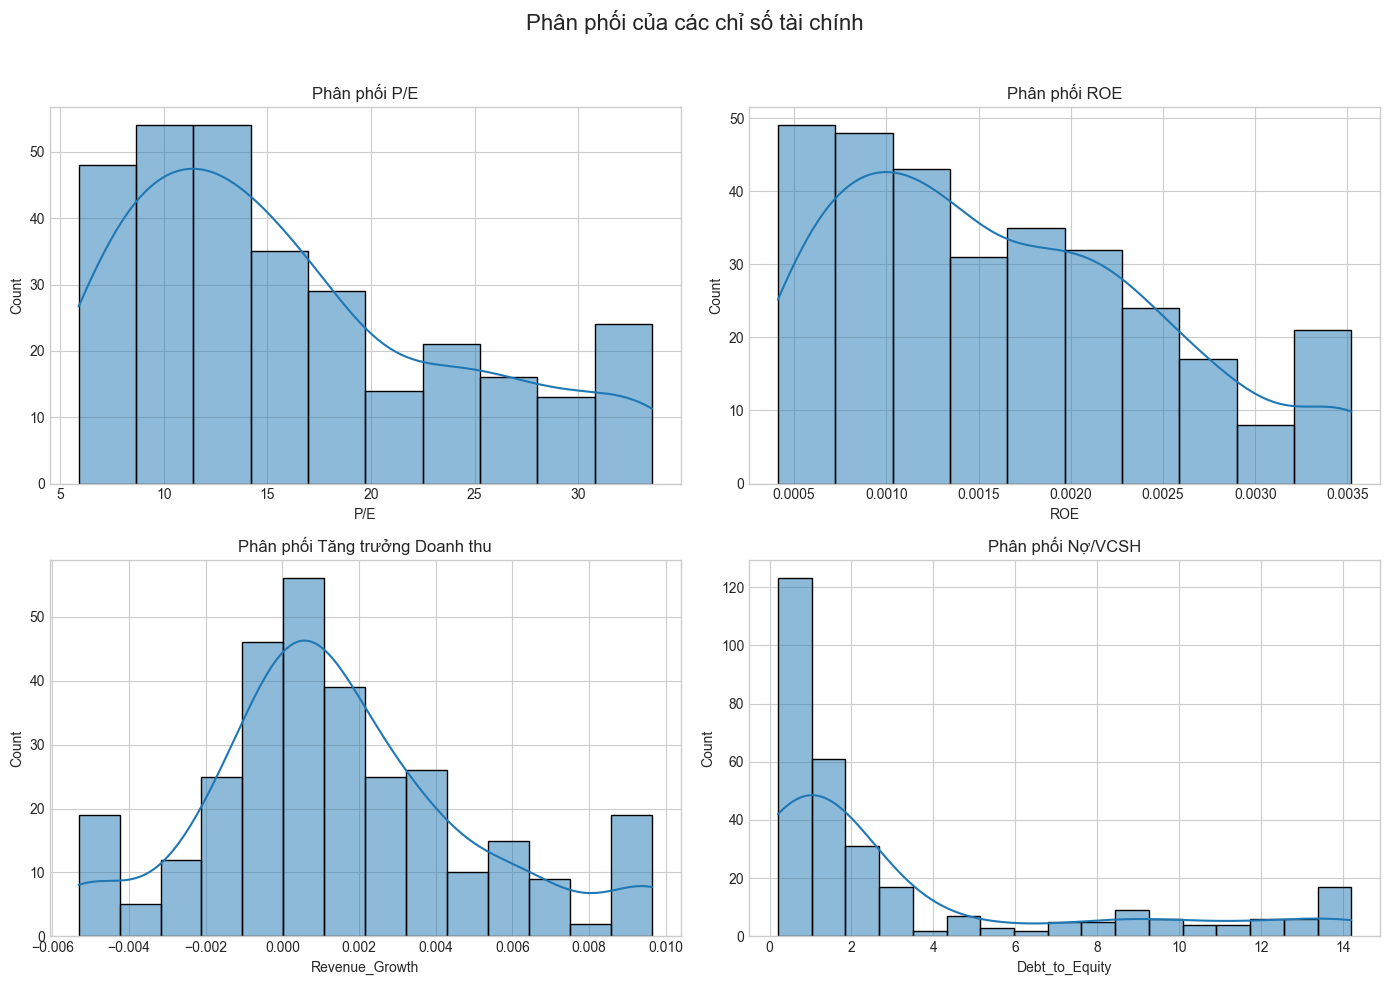


--- 3. Ma trận tương quan giữa các biến ---


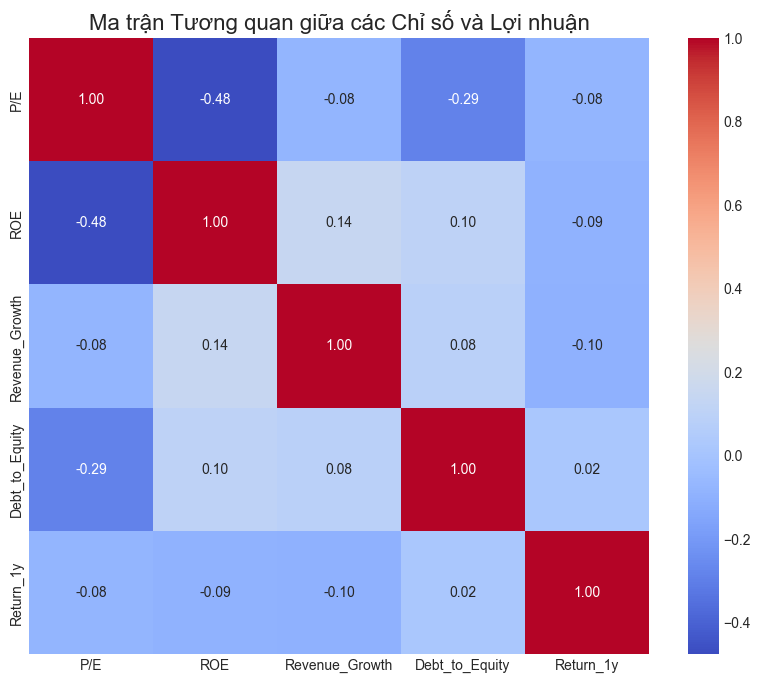

In [33]:
from scipy.stats.mstats import winsorize

df_cleaned = df_analysis.copy()
cols_to_winsorize = ['P/E', 'ROE', 'Revenue_Growth', 'Debt_to_Equity', 'Return_1y']

for col in cols_to_winsorize:
    # limits=[0.05, 0.05] nghĩa là cắt 5% thấp nhất và 5% cao nhất
    df_cleaned[col] = winsorize(df_cleaned[col], limits=[0.05, 0.05])
    
perform_eda(df_cleaned)



==================== BẮT ĐẦU KIỂM ĐỊNH BẪY GIÁ TRỊ ====================

--- Phân tích cho năm hình thành danh mục: 2020 ---
Kết quả phân loại theo Composite Quality Score:
  Lợi nhuận TB nhóm chất lượng cao: 80.53%
  Lợi nhuận TB nhóm chất lượng thấp: 69.17%
  T-statistic: 0.3867, P-value: 0.3520
  => KẾT LUẬN: Không có sự khác biệt ý nghĩa thống kê.

--- Phân tích cho năm hình thành danh mục: 2021 ---
Kết quả phân loại theo Composite Quality Score:
  Lợi nhuận TB nhóm chất lượng cao: -46.01%
  Lợi nhuận TB nhóm chất lượng thấp: -35.72%
  T-statistic: -1.5534, P-value: 0.9320
  => KẾT LUẬN: Không có sự khác biệt ý nghĩa thống kê.

--- Phân tích cho năm hình thành danh mục: 2022 ---
Kết quả phân loại theo Composite Quality Score:
  Lợi nhuận TB nhóm chất lượng cao: 29.56%
  Lợi nhuận TB nhóm chất lượng thấp: 48.01%
  T-statistic: -1.2608, P-value: 0.8879
  => KẾT LUẬN: Không có sự khác biệt ý nghĩa thống kê.

--- Phân tích cho năm hình thành danh mục: 2023 ---
Kết quả phân loại theo 

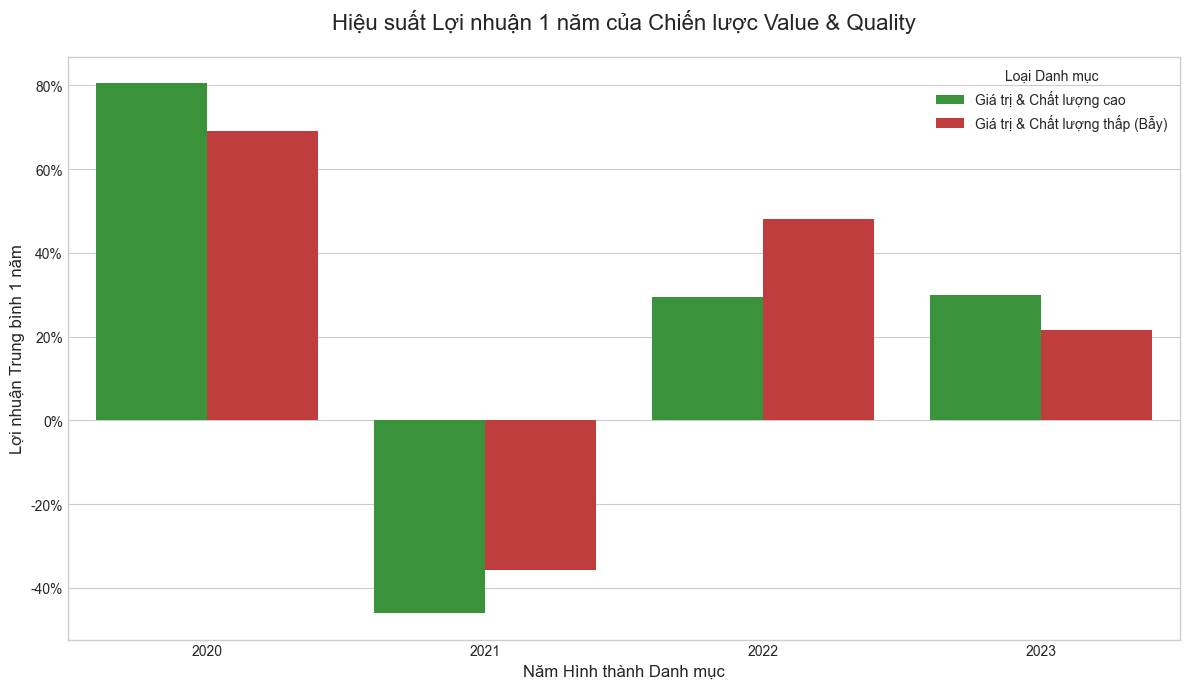

In [35]:
# Thực hiện kiểm định tổng hợp
analysis_years = sorted(df_cleaned['Formation_Year'].unique())
all_results = []

print("\n\n" + "="*20 + " BẮT ĐẦU KIỂM ĐỊNH BẪY GIÁ TRỊ " + "="*20)
for year in analysis_years:
    print(f"\n--- Phân tích cho năm hình thành danh mục: {year} ---")
    df_year_data = df_main[df_main['Formation_Year'] == year]
    
    # Chạy kiểm định với chỉ số chất lượng tổng hợp
    result = perform_double_sort_and_test_all(df_year_data, value_metric='P/E')
    
    if result:
        # In kết quả chi tiết cho từng năm
        print(f"Kết quả phân loại theo Composite Quality Score:")
        print(f"  Lợi nhuận TB nhóm chất lượng cao: {result['high_quality_return']:.2%}")
        print(f"  Lợi nhuận TB nhóm chất lượng thấp: {result['low_quality_return']:.2%}")
        print(f"  T-statistic: {result['t_statistic']:.4f}, P-value: {result['p_value']:.4f}")
        if result['p_value'] < 0.05:
            print("  => KẾT LUẬN: Có ý nghĩa thống kê. Nhóm chất lượng cao hoạt động tốt hơn.")
        else:
            print("  => KẾT LUẬN: Không có sự khác biệt ý nghĩa thống kê.")
        
        # Thêm cột năm vào kết quả để tổng hợp
        result['year'] = year
        all_results.append(result)

# 3. Tổng hợp và Trực quan hóa kết quả
if all_results:
    visualize_result_all(all_results)
else:
    print("\nKhông có đủ dữ liệu để tạo kết quả tổng hợp.")


==================== PHÂN TÍCH CHO NĂM 2020 - Dựa trên chỉ số ROE ====================
Tìm thấy 23 cổ phiếu trong nhóm P/E thấp (ngưỡng P/E <= 11.30).
Phân nhóm theo ROE (cao là tốt): Ngưỡng >= 0.00

--- Kết quả Hiệu suất Danh mục ---
Nhóm Low P/E - High ROE:
  Số lượng CP: 12
  Lợi nhuận TB 1 năm: 80.29%
Nhóm Low P/E - Low ROE (Value Trap):
  Số lượng CP: 11
  Lợi nhuận TB 1 năm: 69.43%

--- Kết quả Kiểm định Giả thuyết (T-test) ---
T-statistic: 0.3686
P-value (one-tailed): 0.3584
Kết luận: Tại mức ý nghĩa 5.0%, không có đủ bằng chứng thống kê để bác bỏ H0.
==> Không có sự khác biệt đáng kể về lợi nhuận giữa hai nhóm.

==================== PHÂN TÍCH CHO NĂM 2020 - Dựa trên chỉ số Revenue_Growth ====================
Tìm thấy 23 cổ phiếu trong nhóm P/E thấp (ngưỡng P/E <= 11.30).
Phân nhóm theo Revenue_Growth (cao là tốt): Ngưỡng >= 0.00

--- Kết quả Hiệu suất Danh mục ---
Nhóm Low P/E - High Revenue_Growth:
  Số lượng CP: 12
  Lợi nhuận TB 1 năm: 84.31%
Nhóm Low P/E - Low Revenue_Grow

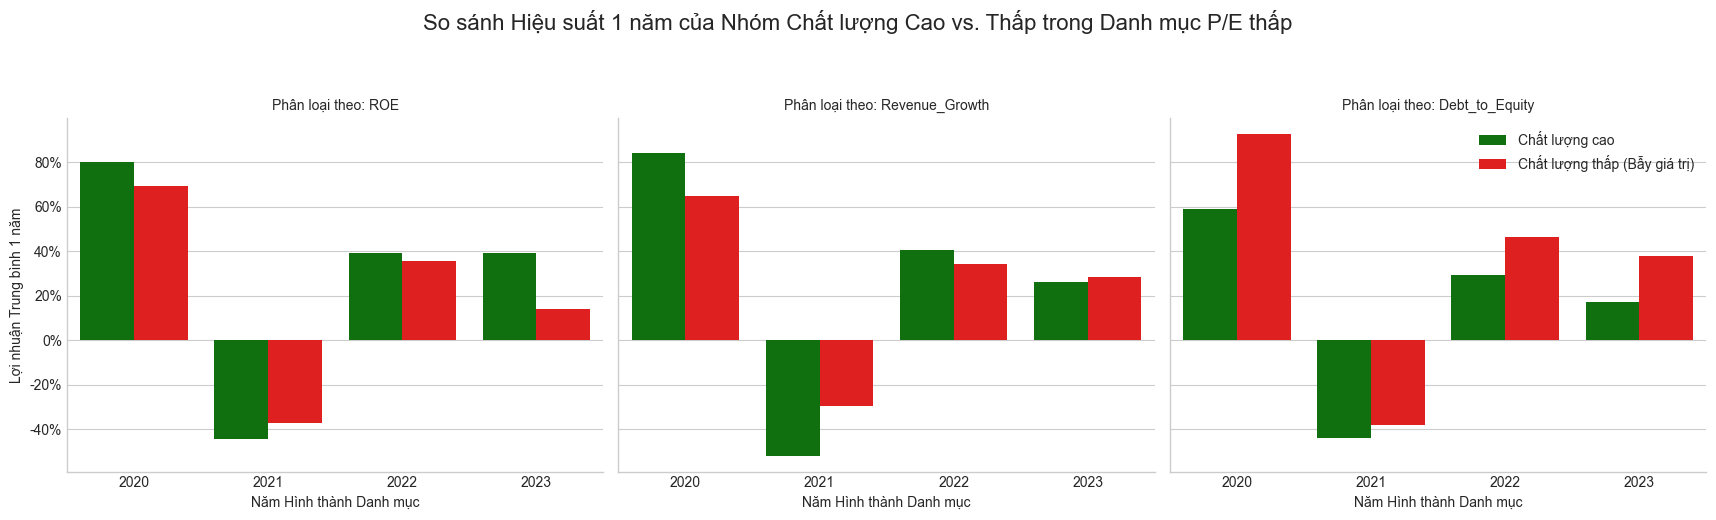

In [ ]:
# Thực hiện kiểm định các yếu tố riêng lẻ
analysis_years = df_cleaned['Formation_Year'].unique()
quality_metrics_to_test = ['ROE', 'Revenue_Growth', 'Debt_to_Equity']
all_results = []

for year in analysis_years:
    for metric in quality_metrics_to_test:
        _, _, result_data = perform_double_sort_and_test_each(df_analysis, year, quality_metric=metric)
        if result_data:
            all_results.append(result_data)

if all_results:
    visualize_result_each(all_results)
else:
    print("\nKhông có đủ dữ liệu để tạo kết quả tổng hợp.")

#### Nhận xét

Kết quả Kiểm định "Bẫy Giá trị"

Phát hiện chính: Hầu hết các chỉ số chất lượng riêng lẻ (ROE, Tăng trưởng Doanh thu, Tỷ lệ Nợ) không phải là công cụ đáng tin cậy và nhất quán để phân biệt cổ phiếu giá trị hiệu suất cao với bẫy giá trị trên thị trường Việt Nam trong giai đoạn 2020-2023. 

Điều này thách thức niềm tin phổ biến rằng chỉ cần nhìn vào ROE hay tăng trưởng là đủ.

Đặc biệt: Kết quả của ROE trong năm 2023 (p-value = 0.0259).

Tuy nhiên, có một ngoại lệ đáng chú ý. Trong năm 2023, yếu tố ROE đã cho thấy khả năng phân loại hiệu quả, khi nhóm cổ phiếu P/E thấp & ROE cao mang lại lợi nhuận vượt trội (39.23%) so với nhóm P/E thấp & ROE thấp (13.89%), và sự khác biệt này có ý nghĩa thống kê. Điều này gợi ý rằng vai trò của các yếu tố chất lượng có thể phụ thuộc vào chu kỳ kinh tế và bối cảnh thị trường. Trong một thị trường phục hồi và có sự phân hóa mạnh, các nhà đầu tư có xu hướng tìm về những doanh nghiệp có nền tảng vững chắc (thể hiện qua ROE cao).

**Thảo luận về sự nhiễu của thị trường:**

Năm 2020 (Uptrend mạnh sau Covid): Hầu hết mọi thứ đều tăng giá. Dòng tiền "điên" có thể đã làm lu mờ sự khác biệt về chất lượng. Lợi nhuận 80% và 69% đều rất cao.

Năm 2022 (Downtrend mạnh): Hầu hết mọi thứ đều giảm giá. Cổ phiếu tốt cũng bị bán tháo. Lợi nhuận của cả hai nhóm đều âm nặng, cho thấy yếu tố chất lượng không thể chống lại được xu hướng chung của thị trường.

Điều này cho thấy chiến lược đầu tư giá trị (dù có lọc chất lượng hay không) vẫn chịu ảnh hưởng rất lớn từ yếu tố thị trường chung (beta).

Kết luận chung: 

Kết quả từ Phần I cho thấy việc chỉ dựa vào các chỉ số tài chính tại một thời điểm để lựa chọn cổ phiếu cho cả một năm là một chiến lược có độ không chắc chắn cao và bị ảnh hưởng mạnh bởi xu hướng thị trường. Điều này đặt ra một câu hỏi khác cho nhà đầu tư: Thay vì cố gắng chọn cổ phiếu cho dài hạn, liệu chúng ta có thể dự báo được xu hướng giá trong ngắn hạn để hỗ trợ các quyết định giao dịch linh hoạt hơn không?

Phần II sẽ đi sâu vào việc so sánh hai phương pháp dự báo chuỗi thời gian phổ biến, ARIMA và Prophet, trên các cổ phiếu đại diện. Chọn các cổ phiếu có đặc tính khác nhau để xem liệu có một mô hình nào tỏ ra vượt trội và phù hợp với thị trường Việt Nam hay không?

## Phần II

In [ ]:
def prepare_price_data(symbol, start_date, end_date):
    print(f"Đang tải dữ liệu giá cho {symbol}...")
    try:
        stock = Vnstock().stock(symbol=symbol, source='VCI')
        df = stock.quote.history(start=start_date, end=end_date, interval='1D')
        
        df['time'] = pd.to_datetime(df['time'])
        df.set_index('time', inplace=True)
        df.sort_index(inplace=True)
        
        price_series = df['close'].rename('price')
        # 1. Chuyển sang tần suất ngày làm việc
        price_series = price_series.asfreq('B')
        # 2. Điền các ngày nghỉ bằng giá trị của ngày trước đó
        price_series.fillna(method='ffill', inplace=True)
        price_series.dropna(inplace=True)
        
        time.sleep(1)
        return price_series
    except Exception as e:
        print(f"Lỗi: {e}")
        return pd.Series(dtype='float64')

def walk_forward_validation(data, n_train, n_test_steps, model_func, model_name, **kwargs):
    predictions, test_set = [], []
    print(f"\nBắt đầu Walk-Forward Validation cho mô hình {model_name}...")
    for i in range(n_test_steps):
        train = data[:n_train + i]
        test_y = data.iloc[n_train + i]
        prediction = model_func(train, **kwargs)
        predictions.append(prediction)
        test_set.append(test_y)
        print(f"\r  Đang dự báo bước {i+1}/{n_test_steps}...", end="")
    print("\n  Hoàn thành.")
    return predictions, test_set

def find_best_arima_order(train_data, max_d=2):
    """Xác định bậc d và chọn p, q một cách tự động."""
    d = 0
    temp_series = train_data.copy()
    for i in range(max_d + 1):
        try:
            adf_result = adfuller(temp_series)
            if adf_result[1] < 0.05:
                d = i
                break
            temp_series = temp_series.diff().dropna()
            if temp_series.empty: # Nếu sai phân làm mất hết dữ liệu
                d = i
                break
        except:
            d = i # Nếu có lỗi, dùng bậc sai phân hiện tại
            break
    if i == max_d: d = max_d
    p, q = 1, 1 # Chọn p, q đơn giản để tự động hóa
    return (p, d, q)

def arima_forecast_price_manual(train_data):
    """
    Huấn luyện mô hình ARIMA với các tham số (p,d,q) được xác định thủ công/bán tự động.
    """
    try:
        # Xác định order (p,d,q)
        order = find_best_arima_order(train_data)
        
        # Huấn luyện mô hình
        model = ARIMA(train_data, order=order)
        model_fit = model.fit()
        
        # Dự báo 1 bước
        forecast = model_fit.forecast(steps=1).iloc[0]
        return forecast
    except Exception as e:
        return train_data.iloc[-1]

def prophet_forecast_price(train_data, holidays_df):
    """Huấn luyện và dự báo với Prophet."""
    try:
        df_prophet = train_data.reset_index(); df_prophet.columns = ['ds', 'y']
        model = Prophet(holidays=holidays_df, daily_seasonality=False)# Tắt daily vì có thể gây nhiễu
        model.fit(df_prophet)
        future = model.make_future_dataframe(periods=1)
        forecast = model.predict(future)
        return forecast['yhat'].iloc[-1]
    except Exception:
        return train_data.iloc[-1]

def run_forecasting_comparison(symbol, start_date, end_date):
    """Thực hiện toàn bộ quy trình so sánh ARIMA và Prophet cho một cổ phiếu."""
    print(f"\n{'='*20} PHÂN TÍCH DỰ BÁO CHO MÃ: {symbol} {'='*20}")
    
    price_series = prepare_price_data(symbol, start_date, end_date)
    if price_series.empty or len(price_series) < 500: # Yêu cầu tối thiểu dữ liệu
        print(f"  Không đủ dữ liệu lịch sử cho {symbol} để thực hiện kiểm định.")
        return None

    N_TEST_STEPS = 252 
    N_TRAIN = len(price_series) - N_TEST_STEPS
    if N_TRAIN < 252:
        print(f"  Không đủ dữ liệu huấn luyện cho {symbol}.")
        return None

    arima_preds, y_test = walk_forward_validation(price_series, N_TRAIN, N_TEST_STEPS, arima_forecast_price_manual, "ARIMA")
    
    vn_holidays = make_holidays_df(year_list=list(range(int(start_date[:4]), int(end_date[:4]) + 1)), country='VN')
    prophet_preds, _ = walk_forward_validation(price_series, N_TRAIN, N_TEST_STEPS, prophet_forecast_price, "Prophet", holidays_df=vn_holidays)

    y_test_np = np.array(y_test)
    arima_preds_np = np.array(arima_preds)
    prophet_preds_np = np.array(prophet_preds)

    metrics = {}
    for model_name, preds in [('ARIMA', arima_preds_np), ('Prophet', prophet_preds_np)]:
        metrics[model_name] = {
            'RMSE': np.sqrt(mean_squared_error(y_test_np, preds)),
            'MAE': mean_absolute_error(y_test_np, preds),
            'MAPE (%)': mean_absolute_percentage_error(y_test_np, preds) * 100
        }
    
    dm_result = dm_test(y_test_np, arima_preds_np, prophet_preds_np)
    
    return {
            'symbol': symbol,
            'metrics': pd.DataFrame(metrics).T,
            'dm_statistic': dm_result[0],  # Lấy giá trị thống kê từ tuple
            'dm_p_value': dm_result[1],   # Lấy p-value từ tuple
            'actual': y_test_np,
            'arima_forecast': arima_preds_np,
            'prophet_forecast': prophet_preds_np,
            'test_dates': price_series.index[N_TRAIN:]
        }



==================== PHÂN TÍCH DỰ BÁO CHO MÃ: LPB ====================
Đang tải dữ liệu giá cho LPB...


Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



Bắt đầu Walk-Forward Validation cho mô hình ARIMA...
  Đang dự báo bước 91/252...

Maximum Likelihood optimization failed to converge. Check mle_retvals


  Đang dự báo bước 202/252...

...

  Đang dự báo bước 164/252...

Maximum Likelihood optimization failed to converge. Check mle_retvals


  Đang dự báo bước 213/252...

Maximum Likelihood optimization failed to converge. Check mle_retvals


  Đang dự báo bước 252/252...
  Hoàn thành.

Bắt đầu Walk-Forward Validation cho mô hình Prophet...
  Đang dự báo bước 252/252...
  Hoàn thành.


==================== BẢNG TỔNG HỢP KẾT QUẢ ĐÃ LƯU VÀO 'forecast_comparison_summary.csv' ====================
  Symbol  ARIMA_RMSE  Prophet_RMSE  ARIMA_MAE  Prophet_MAE  ARIMA_MAPE  \
0    LPB      0.4756        2.0217     0.3179       1.6082      1.0986   
1    VIC      1.4311       12.8749     0.7353       8.7662      1.2081   
2    TPB      0.2220        1.2975     0.1473       0.9951      1.0431   

   Prophet_MAPE  DM_Statistic  DM_P_Value  
0        5.4159      -12.6410         0.0  
1       13.5030       -8.9826         0.0  
2        7.0229      -10.3721         0.0  

--- Phân tích Chi tiết cho mã: LPB ---
Bảng so sánh chỉ số lỗi:
           RMSE     MAE  MAPE (%)
ARIMA    0.4756  0.3179    1.0986
Prophet  2.0217  1.6082    5.4159

Kiểm định Diebold-Mariano:
  DM-Statistic: -12.6410, P-value: 0.0000
  => Kết luận: Có sự khác biệt ý ng

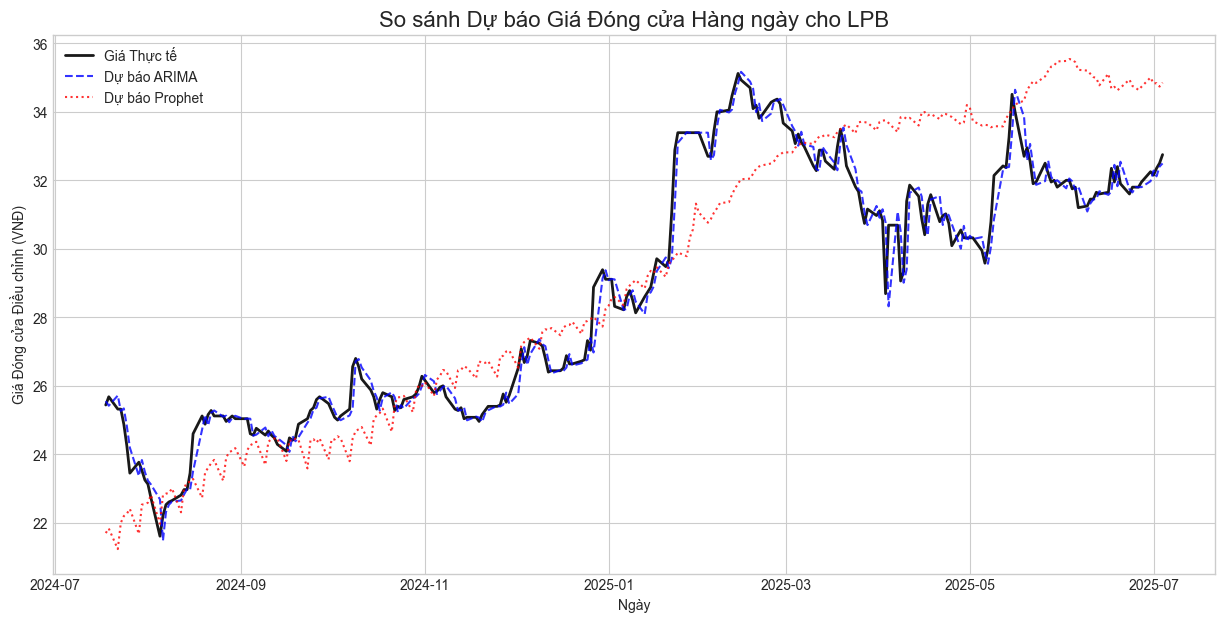


--- Phân tích Chi tiết cho mã: VIC ---
Bảng so sánh chỉ số lỗi:
            RMSE     MAE  MAPE (%)
ARIMA     1.4311  0.7353    1.2081
Prophet  12.8749  8.7662   13.5030

Kiểm định Diebold-Mariano:
  DM-Statistic: -8.9826, P-value: 0.0000
  => Kết luận: Có sự khác biệt ý nghĩa thống kê. Mô hình ARIMA tốt hơn.


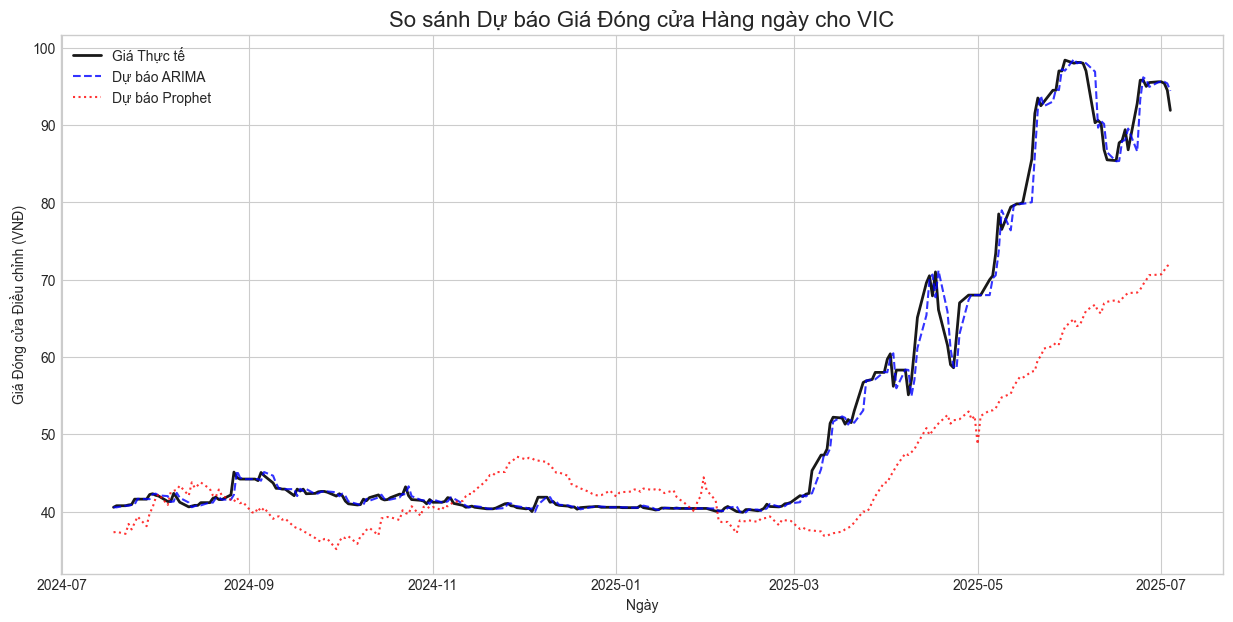


--- Phân tích Chi tiết cho mã: TPB ---
Bảng so sánh chỉ số lỗi:
           RMSE     MAE  MAPE (%)
ARIMA    0.2220  0.1473    1.0431
Prophet  1.2975  0.9951    7.0229

Kiểm định Diebold-Mariano:
  DM-Statistic: -10.3721, P-value: 0.0000
  => Kết luận: Có sự khác biệt ý nghĩa thống kê. Mô hình ARIMA tốt hơn.


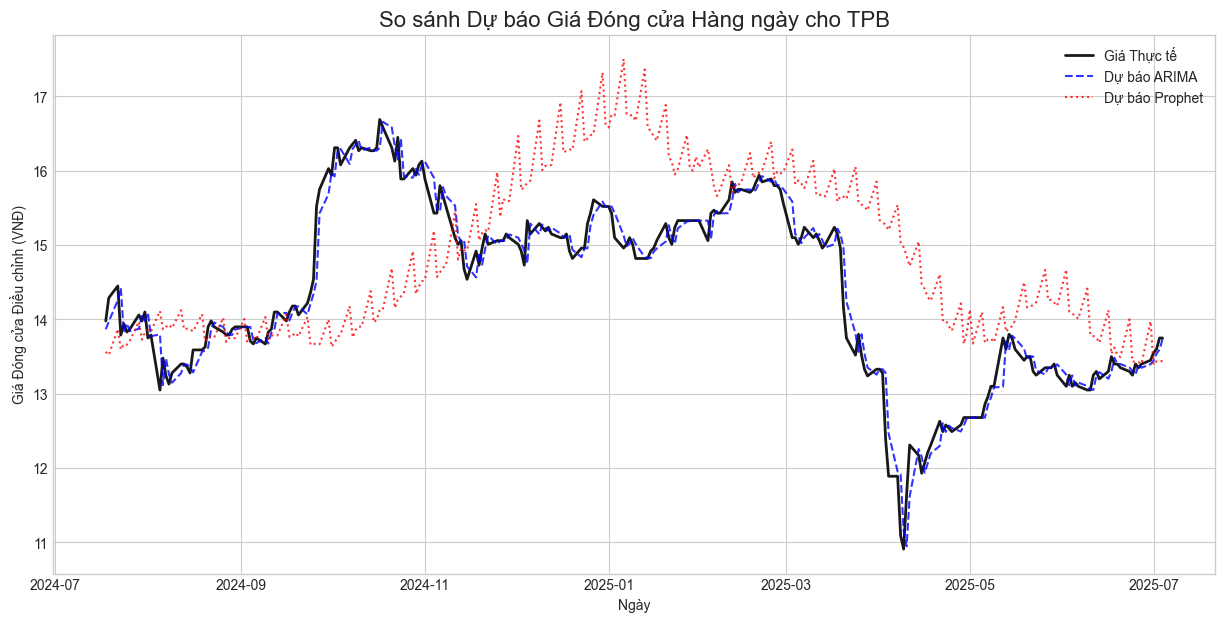

In [56]:
#symbols_for_forecasting = ['LPB', 'VHM', 'VIC', 'TPB', 'SHB']
symbols_for_forecasting = ['LPB', 'VIC', 'TPB']

forecasting_start_date = '2020-01-01'
# Lấy đến ngày hiện tại để có dữ liệu mới nhất
forecasting_end_date = datetime.now().strftime('%Y-%m-%d')

all_forecast_results = []
for symbol in symbols_for_forecasting:
    result = run_forecasting_comparison(symbol, forecasting_start_date, forecasting_end_date)
    if result:
        all_forecast_results.append(result)

if not all_forecast_results:
    print("\nKhông có đủ dữ liệu để thực hiện phân tích.")
else:
    # **CẢI TIẾN: TỔNG HỢP VÀ LƯU KẾT QUẢ VÀO FILE CSV**
    summary_list = []
    for res in all_forecast_results:
        arima_metrics = res['metrics'].loc['ARIMA']
        prophet_metrics = res['metrics'].loc['Prophet']
        summary_list.append({
            'Symbol': res['symbol'],
            'ARIMA_RMSE': arima_metrics['RMSE'],
            'Prophet_RMSE': prophet_metrics['RMSE'],
            'ARIMA_MAE': arima_metrics['MAE'],
            'Prophet_MAE': prophet_metrics['MAE'],
            'ARIMA_MAPE': arima_metrics['MAPE (%)'],
            'Prophet_MAPE': prophet_metrics['MAPE (%)'],
            'DM_Statistic': res['dm_statistic'],
            'DM_P_Value': res['dm_p_value']
        })
    
    summary_df = pd.DataFrame(summary_list)
    summary_df.to_csv('forecast_comparison_summary.csv', index=False, encoding='utf-8-sig')
    print("\n\n" + "="*20 + " BẢNG TỔNG HỢP KẾT QUẢ ĐÃ LƯU VÀO 'forecast_comparison_summary.csv' " + "="*20)
    print(summary_df.round(4))
    
    # In ra kết luận và vẽ đồ thị
    for result in all_forecast_results:
        print(f"\n--- Phân tích Chi tiết cho mã: {result['symbol']} ---")
        print("Bảng so sánh chỉ số lỗi:")
        print(result['metrics'].round(4))
        print("\nKiểm định Diebold-Mariano:")
        print(f"  DM-Statistic: {result['dm_statistic']:.4f}, P-value: {result['dm_p_value']:.4f}")
        if result['dm_p_value'] < 0.05:
            winner = 'ARIMA' if result['metrics'].loc['ARIMA', 'RMSE'] < result['metrics'].loc['Prophet', 'RMSE'] else 'Prophet'
            print(f"  => Kết luận: Có sự khác biệt ý nghĩa thống kê. Mô hình {winner} tốt hơn.")
        else:
            print("  => Kết luận: Không có sự khác biệt ý nghĩa thống kê về hiệu quả dự báo.")
        
        # Trực quan hóa
        plt.style.use('seaborn-v0_8-whitegrid')
        plt.figure(figsize=(15, 7))
        plt.plot(result['test_dates'], result['actual'], label='Giá Thực tế', color='black', alpha=0.9, linewidth=2)
        plt.plot(result['test_dates'], result['arima_forecast'], label='Dự báo ARIMA', color='blue', linestyle='--', alpha=0.8)
        plt.plot(result['test_dates'], result['prophet_forecast'], label='Dự báo Prophet', color='red', linestyle=':', alpha=0.8)
        plt.title(f'So sánh Dự báo Giá Đóng cửa Hàng ngày cho {result["symbol"]}', fontsize=16)
        plt.xlabel('Ngày'); plt.ylabel('Giá Đóng cửa Điều chỉnh (VNĐ)'); plt.legend(); plt.grid(True)
        plt.show()